# Problem Statement

## Business Context

As organizations grow and scale, they are often inundated with large volumes of data, reports, and documents that contain critical information for decision-making. In real-world business settings, such as venture capital firms like Andreesen Horowitz, business analysts are required to sift through large datasets, research papers, or reports to extract relevant information that impacts strategic decisions.

For instance, consider that you've just joined Andreesen Horowitz, a renowned venture capital firm, and you are tasked with analyzing a dense report like the Harvard Business Review's **"How Apple is Organized for Innovation."** Going through the report manually can be extremely time-consuming as the size and complexity of these report increases. However, by using **Semantic Search** and **Retrieval-Augmented Generation (RAG)** models, you can significantly streamline this process.

Imagine having the capability to directly ask questions like, “How does Apple structure its teams for innovation?” and get immediate, relevant answers drawn from the report. This ability to extract and organize specific insights quickly and accurately enables you to focus on higher-level analysis and decision-making, rather than being bogged down by information retrieval.

## Objective

The goal is to develop a RAG application that helps business analysts efficiently extract key insights from extensive reports, such as “How Apple is Organized for Innovation.”

Specifically, the system aims to:

- Answer user queries by retrieving relevant content directly from lengthy documents.

- Support natural-language interaction without requiring a full manual read-through.

- Act as an intelligent assistant that streamlines the report analysis process.

Through this solution, analysts can save time, improve productivity, and make faster, more informed strategic decisions

## Data Description

**How Apple is Organized for Innovation** - An article of 11 pages in pdf format

## Installing and Importing Necessary Libraries and Dependencies

In [17]:
# Install required libraries
!pip install -q langchain_community==0.3.27 \
              langchain==0.3.27 \
              chromadb==1.0.15 \
              pymupdf==1.26.3 \
              tiktoken==0.9.0 \
              datasets==4.0.0 \
              evaluate==0.4.5 \
              langchain_openai==0.3.30

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [18]:
# Import core libraries
import os                                                                       # Interact with the operating system (e.g., set environment variables)
import json                                                                     # Read/write JSON data

# Import libraries for working with PDFs and OpenAI
from langchain.document_loaders import PyMuPDFLoader                            # Load and extract text from PDF files
from openai import OpenAI                                                       # Access OpenAI's models and services

# Import libraries for processing dataframes and text
import tiktoken                                                                 # Tokenizer used for counting and splitting text for models
import pandas as pd                                                             # Load, manipulate, and analyze tabular data

# Import LangChain components for data loading, chunking, embedding, and vector DBs
from langchain.text_splitter import RecursiveCharacterTextSplitter              # Break text into overlapping chunks for processing
from langchain.embeddings.openai import OpenAIEmbeddings                        # Create vector embeddings using OpenAI's models  # type: ignore
from langchain.vectorstores import Chroma                                       # Store and search vector embeddings using Chroma DB  # type: ignore


from datasets import Dataset                                                    # Used to structure the input (questions, answers, contexts etc.) in tabular format
from langchain_openai import ChatOpenAI                                         # This is needed since LLM is used in metric computation

from google.colab import userdata                                               # Used to extract configurable notebook secrets from the colab secrete store
from google.colab import drive                                                  # Used to mount Google Drive for accessing files
from glob import glob


## Question Answering using LLM

> **Note 1:** When choosing between an open-source Hugging Face (HF) model and OpenAI’s proprietary model, base your decision on your specific needs. If you opt for a Hugging Face model, make sure to connect to a GPU to execute the code efficiently.

> **Note 2**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:
1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.
2. Switch to a different Google account and resume working on the project from there.
3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

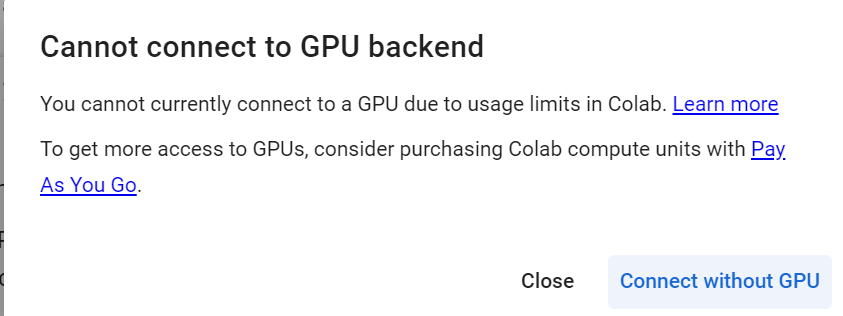

#### Downloading and Loading the model

In [19]:
# Store API credentials in environment variables and populate from Colab Secret Store
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')                                  # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = userdata.get('OPENAI_BASE_URL')                                # Set API base URL as environment variable

# Initialize OpenAI client
client = OpenAI()

In [40]:
#Define a function to get a response from the Model based on prompts within the message list
def getModelResponse(messagesList=None, max_tokens=2000, temperature=0.5, top_p=0.98):

    if messagesList is None:
        raise ValueError("Parameter 'messages' cannot be None")

    # Create a chat completion using the OpenAI client
    completion = client.chat.completions.create(
        model="gpt-4o-mini",                                                    # Specify the model to use
        messages=messagesList,                                                      # User prompt is the input/query to respond to
        max_tokens=max_tokens,                                                  # Max number of tokens to generate in the response
        temperature=temperature,                                                # Controls randomness in output
        top_p=top_p                                                             # Controls diversity via nucleus sampling
    )

    # Return the text content from the model's reply
    return completion.choices[0].message.content

def getModelResponseFromPrompt(user_prompt, max_tokens=1000, temperature=0.3, top_p=0.95):
  messages = [{"role": "user", "content": user_prompt}]         #Define Message List for User Prompt and Role mapping

  #Return the text content from Model Response
  return getModelResponse(messages, max_tokens, temperature, top_p)

#Sample Prompt to confirm connectivity to the Open AI Model by calling the global GetResponse Method.  Uncomment below to Validate
#print(getModelResponseFromPrompt("What is a dog with the highest bite force"))
#msg = [{"role": "user", "content": "What is a dog with the highest bite force"}]
#print(getModelResponse(msg))


### Question 1: Who are the authors of this article and who published this article?

In [41]:
Question_1 = """Who are the authors of this article and who published this article?"""

#Invoke LLM Request and capture the response
initial_prompt_response_1 = getModelResponseFromPrompt(Question_1)
print(initial_prompt_response_1)

I'm sorry, but I can't access external content or databases to retrieve specific articles or their authors. If you provide me with the title or some details about the article, I might be able to help you with general information or context related to it.


The response above cannot be retrieve due to lack of domain details not trained within the model.






### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [42]:
Question_2 = """List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines."""

#Invoke LLM Request and capture the response
initial_prompt_response_2 = getModelResponseFromPrompt(Question_2)
print(initial_prompt_response_2)

- **Vision**: Effective leaders possess a clear and compelling vision for the future, inspiring their team to work towards common goals. This forward-thinking perspective helps to align efforts and motivate individuals to achieve shared objectives.

- **Empathy**: Great leaders demonstrate empathy by understanding and valuing the emotions and perspectives of their team members. This fosters a supportive environment, enhances collaboration, and builds trust within the team.

- **Decisiveness**: Strong leaders are able to make timely and informed decisions, even in uncertain situations. This characteristic instills confidence in their team, as they can rely on their leader to navigate challenges and seize opportunities effectively.


The response above is giving generic responses based on what is already trained within the LLM. No formatting requirements was mentioned in the prompt to suggest how the response should be formatted form the user.

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [43]:
Question_3  = """Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?"""

#Invoke LLM Request and capture the response
initial_prompt_response_3 = getModelResponseFromPrompt(Question_3)
print(initial_prompt_response_3)

I don't have access to specific articles, but I can provide a general overview of how Apple's approach to leadership has historically led to successful innovations. Here are a few key examples:

1. **Visionary Leadership**: Under Steve Jobs, Apple emphasized a clear and compelling vision. Jobs’ focus on design and user experience led to the creation of iconic products like the iPhone and iPad. His ability to articulate a vision helped align the team and fostered a culture of innovation.

2. **Cross-Functional Collaboration**: Apple promotes collaboration across different departments. The development of the Apple Watch involved teams from hardware, software, and health sectors working together to create a product that integrated seamlessly into users' lives. This collaborative approach has been crucial in developing innovative features that set Apple products apart.

3. **Focus on User Experience**: Apple's leadership prioritizes user experience above all. The introduction of the App St

The response above is giving examples from based on what is already trained within the LLM.  However the response does not leverage any details from the knowledge base provided.

## Question Answering using LLM with Prompt Engineering

### Define a system prompt that aligns with the business problem

In [24]:
system_prompt = """You are an AI assistant developed for a technology consulting firm to help support Venture Capital (VC) research teams in efficiently analyzing large volumes of business review reports.

Your primary goal is to streamline the literature review process by:
- Extracting accurate and concise summaries from the reports.
- Identifying key metadata such as authors, publication year, research domain, and methodology.
- Highlighting emerging trends, insights, key topics, and innovations across related works.

When responding:
- Maintain factual accuracy and clarity at all times.
- Present insights in a structured, business-relevant, and easy-to-understand format.
- Avoid speculation or assumptions beyond the provided research content.
- If a query requires information not available in the given papers, acknowledge the limitation instead of inferring.

The objective is to help reviwers and decision-makers quickly discover relevant information, reduce manual review time, and accelerate data-driven innovation.
"""


### Question 1: Who are the authors of this article and who published this article?

In [25]:
#Add Role and Prompt Mapping to Messages List. This will be sent to the LLM via the OpenAI Client
promptMessages_1 = [{"role": "system", "content": system_prompt}, {"role": "user", "content": Question_1}]

#Invoke LLM Request and capture the response
initial_prompt_response_1 = getModelResponse(promptMessages_1)
print(initial_prompt_response_1)

Please provide the title or any specific details about the article you are referring to, so I can assist you in identifying the authors and the publisher.


The system prompt provides details of how the LLM should perform the response, however it lack context data that the LLM needs to properly return the correct response to back to the user.  It's also disclosing it does not know the answer due to the lack of domain information from the Knowledge base.

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [26]:
#Add Role and Prompt Mapping to Messages List. This will be sent to the LLM via the OpenAI Client
promptMessages_2 = [{"role": "system", "content": system_prompt}, {"role": "user", "content": Question_2}]

#Invoke LLM Request and capture the response
secondary_prompt_response_2 = getModelResponse(promptMessages_2)
print(secondary_prompt_response_2)

Here are three key leadership characteristics:

- **Vision**: A strong leader possesses a clear and compelling vision for the future, inspiring and guiding their team towards shared goals and objectives.

- **Empathy**: Effective leaders demonstrate empathy by understanding and valuing the perspectives and emotions of their team members, fostering a supportive and inclusive work environment.

- **Decisiveness**: A decisive leader makes timely and informed decisions, balancing analysis with intuition, which instills confidence in their team and drives progress.


This is formatting the response based on the requirements defined in the system prompt.  However it lacks depth as it does not contain the context data that is provided in the Knowledge base.

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [27]:
#Add Role and Prompt Mapping to Messages List. This will be sent to the LLM via the OpenAI Client
promptMessages_3 = [{"role": "system", "content": system_prompt}, {"role": "user", "content": Question_3}]

#Invoke LLM Request and capture the response
secondary_prompt_response_3 = getModelResponse(promptMessages_3)
print(secondary_prompt_response_3)

I currently do not have access to specific articles or their content. However, I can provide a general overview of Apple's leadership approach and its impact on innovation based on widely known information.

Apple's leadership, particularly under Steve Jobs and now Tim Cook, has been characterized by several key strategies that have led to successful innovations:

1. **Visionary Leadership**: Steve Jobs was known for his strong vision and ability to foresee market trends. His focus on design and user experience led to the creation of iconic products like the iPhone and iPad, which revolutionized their respective markets.

2. **Cross-Functional Collaboration**: Apple fosters a culture of collaboration across different departments. This approach allows for diverse perspectives in product development, leading to innovative solutions that integrate hardware and software seamlessly.

3. **Focus on User Experience**: Apple's leadership prioritizes user experience in product design. This comm

This is formatting the response based on the requirements defined in the system prompt.  However it lacks depth as it does not contain the context data that is provided in the Knowledge base.

## Data Preparation for RAG

### Loading the Data

In [28]:
# Uncomment and add the Knowledge Base File to this directory (if not added already)
# drive.mount('/content/sample_data')

from glob import glob
import os # Import os for path checking

# Path to folder with Knowledge Base
# Ensure 'HBR_How_Apple_Is_Organized_For_Innovation.pdf' is in the '/content/sample_data/' directory
pdf_files = glob("sample_data/HBR_How_Apple_Is_Organized_For_Innovation.pdf")

if not pdf_files:
    print("Error: PDF file 'HBR_How_Apple_Is_Organized_For_Innovation.pdf' not found in 'sample_data/'")
    print("Please upload the file to '/content/sample_data/' or adjust the path.")
    loader = None # Set loader to None to prevent further errors if file is missing
else:
    pdf_file_path = pdf_files[0]
    loader = PyMuPDFLoader(pdf_file_path)

    print(f"Successfully initialized PyMuPDFLoader with: {pdf_file_path}")

all_documents = []
if loader is not None:
    # Load each PDF file and store the documents
    documents = loader.load()
    all_documents.extend(documents)

Successfully initialized PyMuPDFLoader with: sample_data/HBR_How_Apple_Is_Organized_For_Innovation.pdf


### Data Overview

In [29]:
#Render the Documents List Data That was Loaded
all_documents

[Document(metadata={'producer': 'Adobe PDF Library 15.0 (via http://bfo.com/products/pdf?version=2.23.5-r33279)', 'creator': 'Adobe InDesign 14.0 (Macintosh)', 'creationdate': '2020-10-05T14:18:42-04:00', 'source': 'sample_data/HBR_How_Apple_Is_Organized_For_Innovation.pdf', 'file_path': 'sample_data/HBR_How_Apple_Is_Organized_For_Innovation.pdf', 'total_pages': 11, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2020-12-01T18:37:49+00:00', 'trapped': '', 'encryption': 'Standard V2 R3 128-bit RC4', 'modDate': 'D:20201201183749Z', 'creationDate': "D:20201005141842-04'00'", 'page': 0}, page_content='REPRINT R2006F\nPUBLISHED IN HBR\nNOVEMBER–DECEMBER 2020\nARTICLE\nORGANIZATIONAL CULTURE\nHow Apple Is \nOrganized  \nfor Innovation\nIt’s about experts leading experts. \nby Joel M. Podolny and Morten T. Hansen\nThis article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not

### Data Chunking

In [30]:
# Initialize a text splitter that uses OpenAI's token encoder
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',                                                # Encoding used by popular LLMs
    chunk_size=512,                                                             # Each chunk will have up to 512 character
)

# Use the text splitter to divide the PDF content into smaller chunks
document_chunks = text_splitter.split_documents(all_documents)                  # Returns a list of chunked documents

# Verify Total Chuck Output
print(f"Created {len(document_chunks)} chunks.")

Created 29 chunks.


### Embedding

In [31]:
# Initialize the OpenAI Embeddings model with API credentials
embedding_model = OpenAIEmbeddings(
    openai_api_key=os.environ['OPENAI_API_KEY'],                                 # The OpenAI API key for authentication
    openai_api_base=os.environ["OPENAI_BASE_URL"]                                # The OpenAI API base URL endpoint
)

# Generate embeddings (vector representations) for all document chunks
embeddings = embedding_model.embed_documents([chunk.page_content for chunk in document_chunks])

# Check and print the number of embeddings and the dimension of all embedding vectors
print(f"Generated {len(embeddings)} embeddings.")
if embeddings:
    print("Dimension of the embedding vector ", len(embeddings[0]))

Generated 29 embeddings.
Dimension of the embedding vector  1536


### Vector Database

In [32]:
# # Store API credentials in environment variables
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings

# Use HuggingFaceEmbeddings wrapper with SentenceTransformer model
embedding_model = SentenceTransformerEmbeddings(model_name='all-MiniLM-L6-v2')

# Building the vector store and saving it to disk for future use
vectorstore = Chroma.from_documents(
    document_chunks,                                                            # Documents to index
    embedding_model                                                             # Embedding model for converting text to vectors
 )

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Retriever

In [33]:
# Wraping the vector store into a retriever object to fetch the most relevant documents for a given query using similarity search
retriever = vectorstore.as_retriever(
    search_type='similarity',                                                   # Use similarity search (based on vector distance)
    search_kwargs={'k': 10}                                                     # Retrieve top 10 most relevant documents
)

### System Prompt

In [34]:
# Define the system prompt for the model
qna_system_message = """
You are an AI assistant designed to support Venture Capital (VC) research teams in efficiently reviewing technical literature.
Your task is to provide evidence-based, concise, and relevant summaries based on the context provided from business review documentation.

User input will include the necessary context for you to answer their questions. This context will begin with the token:

###Context
The context contains excerpts from one or more business review documents, along with associated metadata such as titles,
authors, abstracts, keywords, and specific sections relevant to the query.

When crafting your response
-Use only the provided context to answer the question.
-If the answer is found in the context, respond with concise and insight-focused summaries.
-Include the paper title and, where applicable, arXiv ID or section reference as the source.
-If no relevant answer exists in the context, respond with: "Sorry, this is out of my knowledge base."
-If the context is not provided, your response should also be: "Sorry, this is out of my knowledge base."


Please adhere to the following response guidelines:
-Provide clear, direct answers using only the given context.
-Present insights in a structured, business-relevant, and easy-to-understand format.
-Do not include any additional information outside of the context.
-Avoid rephrasing or generalizing unless explicitly relevant to the question.
-Avoid speculation or assumptions beyond the provided research content.
-If no relevant answer exists in the context, respond with: "Sorry, this is out of my knowledge base."

The objective is to help reviwers and decision-makers quickly discover relevant information, reduce manual review time, and accelerate data-driven innovation.

Here is an example of how to structure your response:

Answer:
[Answer based on context]

Source:
[Source details with page or section]
"""


### Response Template

In [35]:
# Define the user message template
qna_user_message_template = """
###Context
Here are some responses based on our assessment of the Apple Knowledge base mentioned below:
{context}

###Question
{question}
"""

### Response Function

In [44]:
def generate_rag_response(user_input,k=5,max_tokens=2000,temperature=0.5,top_p=0.98):
    global qna_system_message,qna_user_message_template

    # Retrieve relevant document chunks,
    # Leverage the invoke method, as get_relevant_documents is deprecated
    relevant_document_chunks = retriever.invoke(input=user_input,k=k)
    context_list = [d.page_content for d in relevant_document_chunks]

    # Combine document chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    # Generate the response
    try:
        response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": qna_system_message},
            {"role": "user", "content": user_message}
        ],
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p
        )
        # Extract and print the generated text from the response
        response = response.choices[0].message.content.strip()
    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response

## Question Answering using RAG

### Question 1: Who are the authors of this article and who published this article?

In [37]:
response_with_rag_1 = generate_rag_response(Question_1)
response_with_rag_1

'Answer:\nThe authors of the article "How Apple Is Organized for Innovation" are Joel M. Podolny and Morten T. Hansen. The article was published by Harvard Business Review.\n\nSource:\nHarvard Business Review, November–December 2020.'

The response is clear and concise, and is leveraging context data that the LLM can use to provide an accurate response, as the output includes details from the knowledge base.  

Made adjustments to the temperature setting (.5 -> .3) to reduce the randomness and redundancy of the response.  As the response with a .5 setting included verbiage of the date of the Harvard Business Review creation date.  However with .3 temperature the creation date was not included in the initial response since the date was included under the source section.

**.5 Temperature Reponse**

"The authors of the article are Joel M. Podolny and Morten T. Hansen. The article was published by Harvard Business Review in November–December 2020.

Source:
Harvard Business Review, November–December 2020."

**.3 Temperature Response**

"The authors of the article "How Apple Is Organized for Innovation" are Joel M. Podolny and Morten T. Hansen. The article was published by Harvard Business Review.

Source:
Harvard Business Review, November–December 2020."

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [45]:
response_with_rag_2 = generate_rag_response(Question_2)
response_with_rag_2

'Answer:\n- **Deep Expertise**: Apple leaders are expected to have specialized knowledge in their respective fields, enabling them to engage meaningfully with the work being done within their functions.\n\n- **Immersion in Details**: Leaders are required to be deeply involved in the specifics of their functions, allowing for informed decision-making and oversight.\n\n- **Collaborative Debate**: There is an emphasis on willingness to engage in discussions across functions, facilitating coordinated decision-making by the most qualified individuals.\n\nSource:\nHarvard Business Review, November–December 2020.'

Response is specific based on information within the knowledge base document, which is leveraging context data that the LLM can use to provide an accurate response. 3 specific characteristics were supplied from the response from the LLM which was included in the knowledge base.  

The response was concise and accurate and was outline based on what was defined in the system prompt.  Expanded the number of tokens to achieve a high chance of an accurate response without character truncation.

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [39]:
response_with_rag_3 = generate_rag_response(Question_3)
response_with_rag_3

'Apple\'s approach to leadership, characterized by experts leading experts, has facilitated successful innovations through several key practices:\n\n1. **Expertise in Leadership**: Leaders at Apple are expected to possess deep expertise in their respective areas, allowing them to engage deeply with issues and provide better guidance. This model has proven liberating for employees, fostering an environment where they can excel in their specialized fields.\n\n2. **Collaborative Debate**: Apple promotes a culture of collaborative debate among its hundreds of specialist teams. For instance, the development of the dual-lens camera with portrait mode required collaboration across multiple teams, highlighting how collective expertise drives innovation in product offerings.\n\n3. **Discretionary Leadership Model**: As Apple has grown, leaders have adapted their approach to focus on areas that create the most value. This model allows leaders to delegate less critical tasks, enabling them to con

Response is specific based on information within the knowledge base document, which is leveraging context data that the LLM can use to provide an accurate response.  Also the response includes an specific example noted from the Knowledge base that was specifically applicable to the user prompt.  Also the response was not verbose and but was concise and specific.

## Actionable Insights and Business Recommendations

Actionable Insights:

*   Build Leadership Roles Around Expertise or Subject Matter Expert Knowledge
*   Define a Culture of Constructive Feedback Loops within cross functional teams
*   Institutionalize Detail-Oriented Leadership Practices
*   Engage enterprise learning through Expert Led Knowledge sharing.

Business Recommendations:
*   Redesign leadership job descriptions to emphasize technical mastery or domain expertise as a prerequisite.
*   Encourage leaders to regularly engage with frontline work, customer feedback, and operational data.
*   Adopt Apple’s model of collaborative debate to improve decision quality and break down silos.





<font size=6 color='#4682B4'>Power Ahead</font>
___